In [2]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage import data
from matplotlib import pyplot as plt

In [1]:
def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)

    return mask, ribbon_segment


def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2
    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    gray_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)
    
    # Apply thresholding to get a binary image
    _, black_white = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

    # Normalize the image to range [0, 1] for skeletonization
    black_white_norm = black_white // 255

    skel_img = skeletonize(black_white_norm).astype(np.uint8)

    # Scale the skeletonized image back to [0, 255] for visualization
    skel_img = skel_img * 255

    plt.imshow(skel_img, cmap='gray')
    plt.show()



    


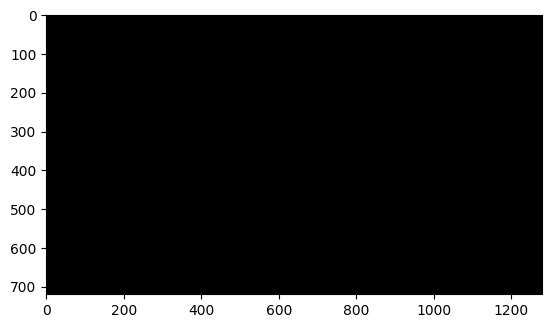

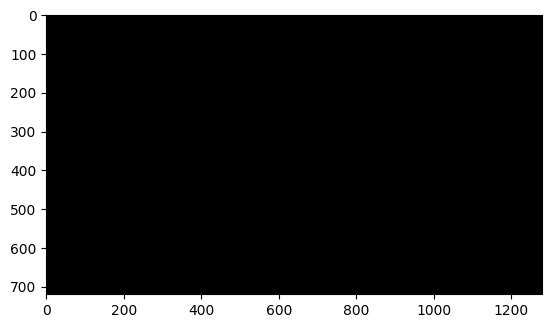

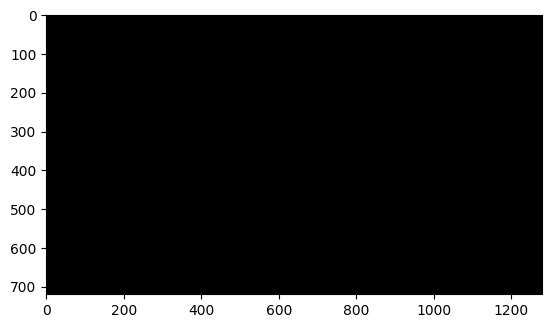

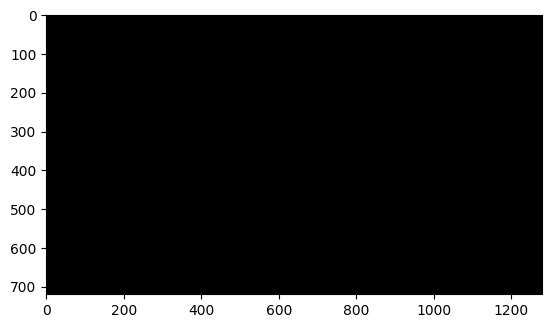

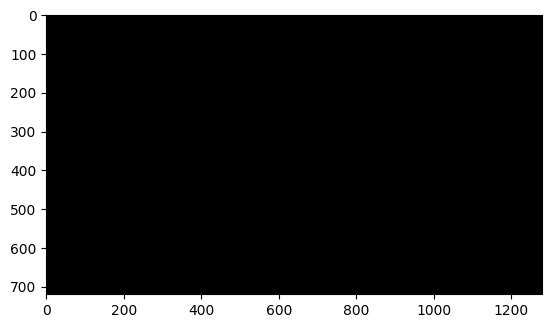

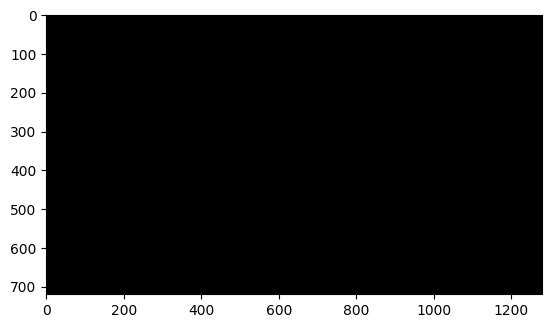

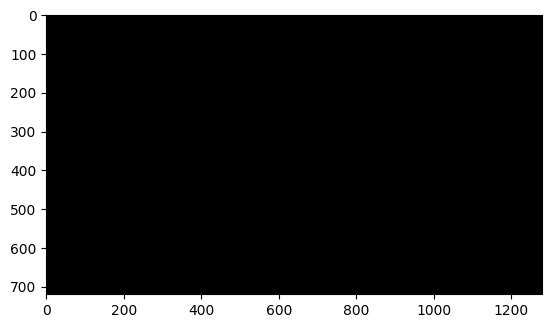

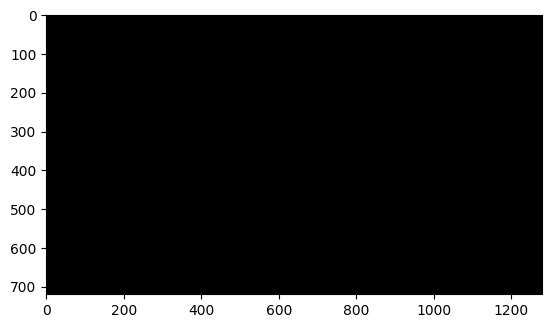

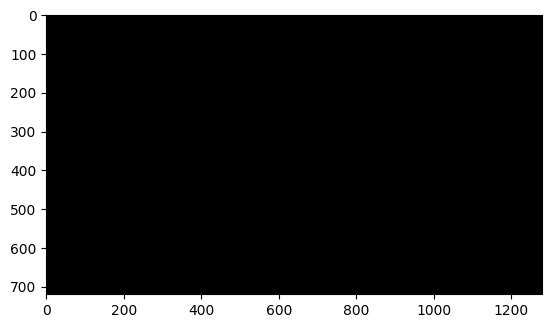

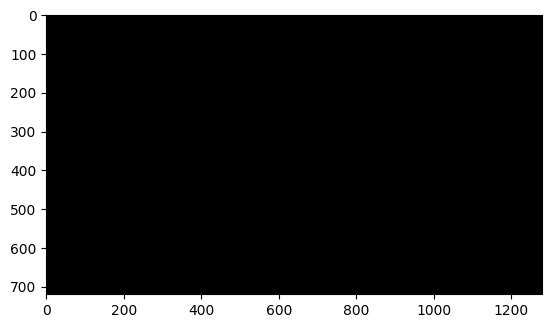

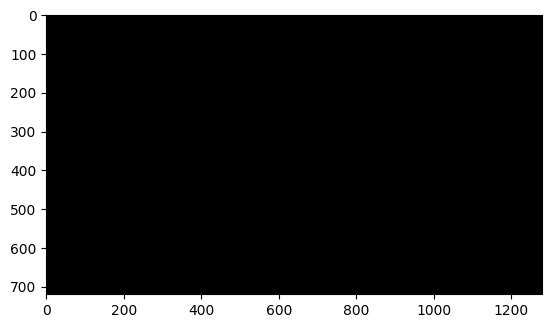

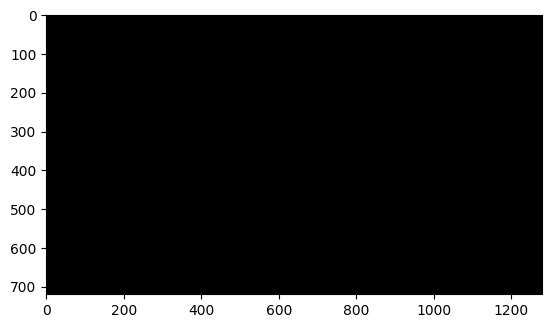

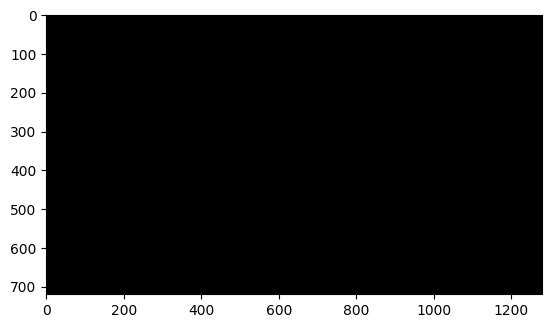

KeyboardInterrupt: 

In [3]:
if __name__ == '__main__':
    cap = cv2.VideoCapture(0)
    while True:
        ret, img = cap.read()
        if not ret:
            print("Capture failed")
            break
        start(img)